# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Agbay, Tristan Michael
- _Student No._: 2024-00281
- _Section_: THU-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1 

![2D Wave Interference from Four Sources.](interference_pattern.png)



This figure displays a two dimensional density plot illustrating the wave interference pattern generated by four distinct point sources. The spatial coordinates extend from negative four to positive four along both the vertical and horizontal axes. A mapped color scale represents the resulting wave amplitudes across the grid to highlight regions of constructive and destructive interference.

### Problem 2 

We transitioned our initial nested loops into a single list comprehension. This successfully reproduced our earlier results, accurately calculating the product from our test matrices without needing explicit append statements.

When dealing with larger matrices, the NumPy @ operator is strongly preferred over our custom function. Native Python lists scatter elements in memory and carry significant interpreter overhead. In contrast, the @ operator relies on heavily optimized C libraries and memory blocks, allowing it to process massive arrays much faster through hardware vectorization.

This exercise also highlights the value of writing idiomatic Python. Using native tools makes the script highly readable, shows clear intent, and removes excess clutter that usually leads to basic bugs. More importantly, while libraries like NumPy are great for the heavy lifting, getting comfortable with idiomatic Python and honing our ability to build our own custom functions is crucial. It ensures we actually understand the logic happening under the hood instead of just relying on black boxes, which is exactly the kind of foundational skill we need when we have to write specialized scripts for our own physics problems later on.

### Other comments
- Doing these two problems made me realize how much time I waste writing clunky code. Building the matrix multiplier with standard loops was tedious but seeing how fast the NumPy operator handles it really put things into perspective. The wave interference problem was also pretty cool because plotting the four sources directly into a density map made the math actually mean something visually.


---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

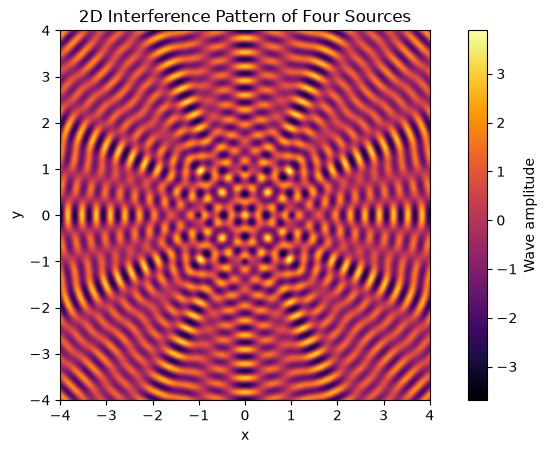

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from math import pi, sin, sqrt

# constants (given)
A = 1
k = (2*pi)/0.3
r_a = (-1, 0)
r_b = (1, 0)
r_c = (0, -1)
r_d = (0, 1)

# Generate values from -4 to 4 for x and y
X = np.linspace(-4, 4, 670)
Y = np.linspace(-4, 4, 670)

# Empty list 
w = []

for y in Y:
    row = [] # Empty list to store y coordinate wave values

    for x in X:
        r0 = sqrt((x - r_a[0])**2 + (y - r_a[1])**2)
        r1 = sqrt((x - r_b[0])**2 + (y - r_b[1])**2)
        r2 = sqrt((x - r_c[0])**2 + (y - r_c[1])**2)  
        r3 = sqrt((x - r_d[0])**2 + (y - r_d[1])**2)  

        # Calculate combined wave at (x, y)
        W = A*sin(k*r0) + A*sin(k*r1) + A*sin(k*r2) + A*sin(k*r3)
        row.append(W) # Add W to the current row

    w.append(row) # Add the completed row to the matrix

# Plotting
plt.imshow(w, cmap ='inferno', extent=[-4, 4, -4, 4]) # Set the plot range from -4 to 4
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Wave amplitude')
plt.axis('square')
plt.title("2D Interference Pattern of Four Sources")
plt.savefig('interference_pattern.png')
plt.show()    

#### Problem 1 code summary

Firstly, I defined the given constants so I do not have to write everything all the time. Then I also simplified the model W(r) by defining a combined wave equation. I used empty lists to store the y-coordinate wave values. Lastly, using Matplotlib, I used imshow() to extend the plot from -4 to 4 for each x and y axis.
---

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [60]:
import random
number = random.randint(1, 9)
number

5

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [61]:
import random

def random_integer_matrix(nrows, ncols):
    row_list = [] # Empty list to store rows of the matrix
    for i in range(nrows): # Repeat process for each row
        # Generate ncols random integers from 1 to 9 for the current row
        sublist = [random.randint(1, 9) for i in range(ncols)]
        row_list.append(sublist) # Add the row to the matrix
    return row_list

random_integer_matrix(3, 4) 

[[2, 5, 5, 9], [7, 6, 4, 7], [7, 4, 2, 4]]

b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [62]:
list1 = [10, 11, 12, 13]
list2 = [14, 15, 16, 17]

def scalar_product(list1, list2):
    summed_result = [] # Empty list to store
    for i in range(len(list1)): 
        # Multiply elements with same index
        summed_result.append(list1[i]*list2[i])
    return sum(summed_result) # Sum of products and total, yay!

print(scalar_product(list1, list2)) # Calculate and print

718


c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [5]:
def transpose_matrix(orig_matrix):
    transposed = []
    for c in range(len(orig_matrix[0])):
        row = []
        for r in range(len(orig_matrix)):
            row.append(orig_matrix[r][c])
        transposed.append(row)
    return transposed

# Demo 3x4 matrix
mat = [[random.randint(1, 10) for _ in range(4)] for _ in range(3)]

print("Original:")
for row in mat:
    print(row)

print("\nTransposed:")
for row in transpose_matrix(mat):
    print(row)

Original:
[8, 5, 8, 9]
[10, 6, 10, 9]
[4, 5, 5, 9]

Transposed:
[8, 10, 4]
[5, 6, 5]
[8, 10, 5]
[9, 9, 9]


d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [6]:
def matrix_multiply(left_matrix, right_matrix):
    if len(left_matrix[0]) != len(right_matrix):
        return "Matrices cannot be multiplied :<"

    right_transposed = transpose_matrix(right_matrix)
    
    result = []
    for row in left_matrix:
        new_row = []
        for col in right_transposed:
            new_row.append(scalar_product(row, col))
        result.append(new_row)
        
    return result

def scalar_product(vec1, vec2):
    return sum(a * b for a, b in zip(vec1, vec2))

left = [[random.randint(1, 10) for _ in range(4)] for _ in range(3)]
right = [[random.randint(1, 10) for _ in range(2)] for _ in range(4)]

print("Product:")
for row in matrix_multiply(left, right):
    print(row)

Product:
[149, 77]
[167, 91]
[205, 114]


#### Problem 2 code summary
I used the transpose_matrix function to transpose the 3 x 4 matrix. Then the matrix_multiply function verifies that the 2 matrices are compatible to have a product. Then I used scalar_product to multiply the two matrices (dot product).


---
## Section 3: Background

### Basics

In [9]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [10]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [11]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [12]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [13]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [14]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [15]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [16]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [17]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [18]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [19]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [20]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [21]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [22]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [23]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [33]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [25]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions
"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [34]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

<img src="figures/gezerlisTable1_1.png" width="67%">

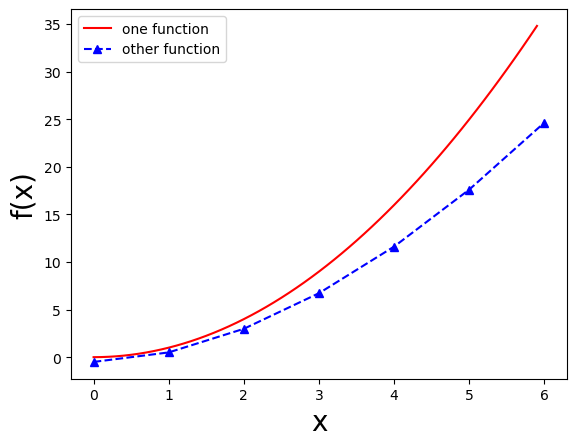

In [27]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

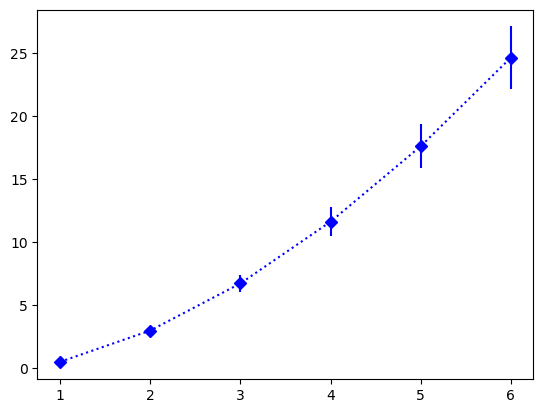

In [29]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [30]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [31]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])

<img src="figures/gezerlisTable1_3.png" width="67%">

<img src="figures/gezerlis_slicingArrays.png" width="67%">

### Visualizing Electric Fields 

The electric field anywhere given a set of $n$ point charges is given by
$$ \mathbf{E}(\mathbf{r}) = \sum_{i=0}^{n-1} kq_i \frac{\mathbf{r} - \mathbf{r}_i}{|\mathbf{r} - \mathbf{r}_i|^3} $$

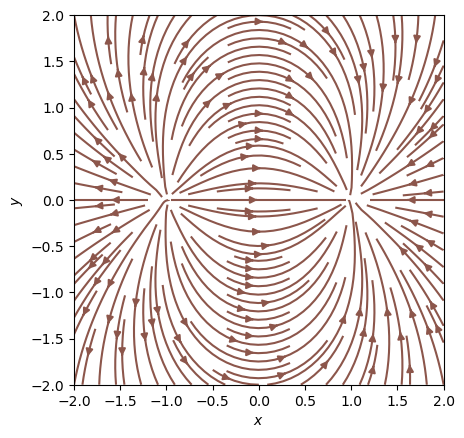

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from copy import deepcopy

def makefield(xs, ys):
    qtopos = {1: (-1,0), -1: (1,0)}
    n = len(xs)
    Exs = [[0. for k in range(n)] for j in range(n)]
    Eys = deepcopy(Exs)
    for j,x in enumerate(xs):
        for k,y in enumerate(ys):
            for q, pos in qtopos.items():
                posx, posy  = pos
                R = sqrt((x - posx)**2 + (y - posy)**2)
                Exs[k][j] += q*(x - posx)/R**3
                Eys[k][j] += q*(y - posy)/R**3
    return Exs, Eys

def plotfield(boxl,n):
    xs = [-boxl + i*2*boxl/(n-1) for i in range(n)]
    ys = xs[:]
    Exs, Eys = makefield(xs, ys)
    xs=np.array(xs); ys=np.array(ys)
    Exs=np.array(Exs); Eys=np.array(Eys)
    plt.streamplot(xs, ys, Exs, Eys, density=1.5, color='tab:brown')
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.axis('square')
    plt.show()
    
plotfield(2., 50)

In [48]:
# sample plotting in notebook and putting saved image in another cell (see Report figure)

import matplotlib.pyplot as plt
import numpy as np

# sample grid and data
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z1 = np.sin(np.sqrt(X**2 + Y**2))        

# create subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# plot on first axs (left)
axs[0].imshow(Z1, cmap='viridis')
axs[0].set_title("Subtitle 1")
axs[0].axis('off')

# plot on the second axis (right)
axs[1].imshow(Z1, cmap='plasma')
axs[1].set_title("Subtitle 2")
axs[1].axis('off')

fig.suptitle("Super title")

# save image locally without rendering in the notebook
plt.savefig('figures/sample.png', bbox_inches='tight', dpi=150)
plt.close()